This code solves the Saint-Venant equations for a steady state flow over a sloping bed (slope i). The Manning-Strickler equation is used for modelling the bed's flow resistance. The numerical solution to the Saint-Venant equations is compared to the solution to the Bresse equation.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from clawpack import riemann
from scipy.integrate import odeint
from IPython.display import HTML 

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.family': 'serif',
    'font.serif': ['Libertinus Serif', 'DejaVu Serif'],
    'font.size': 12,
    'text.usetex': False,
    'mathtext.fontset': 'stix'
})


def bresse(h,x, slope, hn, hc):
    """
    Definition of the Bresse function when flow resistance is modeled using Manning-Strickler
    """
    dhdx = slope * (1 - (hn / h) ** (10./3.)) / (1 - (hc / h) ** 3.)
    return dhdx

def DepthOfInterest(x,h0,hn,hc):
    """
    provides characteristic depths (normal depth and critical depth)
    """
    import numpy as np
    
    if isinstance(x,(np.ndarray,list)):
        m = np.size(x)
        h = np.empty((m))
        for i in range(m):
            h[i] =  hn
    if isinstance(x,(float,int)):
        h =  hn
        
    return h, hn, hc

def flow_animation(claw,K,q,i,L):
    """ Create an animation of the clawpack solution"""
    import matplotlib.animation
    import numpy
    from math import ceil

    x = claw.frames[0].grid.dimensions[0].centers
    x_true = numpy.linspace(0., L , 500)

    h0  = claw.problem_data['initial_depth']
    hn, hc = CharacteristicDepth(K,q,i)
    hmin = 0
    hm = 2 * hn

    fig = plt.figure()
    axes = plt.subplot(1, 1, 1)
    axes.set_xlabel(r'$x$',fontsize=14)
    axes.set_ylabel(r'$h(x, t)$',fontsize=14)
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim(( hmin, hm))
    axes.set_title(" ")
    text = axes.text(L/2, 0.9*hm , '')
 
    def init():
        computed_line, = axes.plot(x[0], claw.frames[0].q[0, :][0], 'r')
        exact_line, = axes.plot(x_true[0], DepthOfInterest(x_true[0],h0,hn,hc)[1], 'k--')
        return  (computed_line, exact_line)
    
    computed_line, exact_line = init()
 
    
    def fplot(n):
        computed_line.set_data([x,], [claw.frames[n].q[0, :]])
        exact_line.set_data([x_true], [DepthOfInterest(x_true,h0,hn,hc)[1]])
        tt = claw.frames[n].t
        val = f'{tt:.2f}'
        text.set_text(r'$ t = {} $ s'.format(val))
        return (computed_line, exact_line)

    frames_to_plot = range(0, len(claw.frames))
    plt.close(fig)
    return matplotlib.animation.FuncAnimation(fig, fplot, frames=frames_to_plot, interval=100,
                                   blit=True, init_func=None, repeat=False)


def CharacteristicDepth(K,q,i):
    """" provides the normal and critical depths associated with slope i 
    and Strickler coefficient K for the inflow rate q """
    import numpy as np
    g = 9.81
    hn = (q / K / np.sqrt(i)) ** (3/5)
    hc = (q ** 2 / g) ** (1 / 3)
    return hn, hc

def racine3(r,q,g):
    """
    Cubic solver for the wave compatibility equation.
    Solves q/h - 2*sqrt(g*h) = r for h.
    After squaring: 4g*h^3 - r^2*h^2 + 2*q*r*h - q^2 = 0
    Solved using Cardano's formula.
    """
    dis = np.sqrt(27*g**4*q**4 - g**3*q**3*r**3)
    a = (216*g**2*q**2 - 36*g*q*r**3 + r**6 + 24*np.sqrt(3.)*dis)**(1./3.)
    r3 = a/(12.*g) + r**2/(12.*g) - (24*g*q*r - r**4)/(12.*a*g)
    return r3


def outlet_bc(state,dim,t,qbc,auxbc,num_ghost):
    """
    Outlet boundary condition adapting to the local flow regime.
    - Subcritical (Fr < 1): one characteristic enters (1-wave, lambda1 = u-c < 0).
      h imposed from outside (h = h_downstream), q computed from the 2-Riemann
      invariant of the last interior cell: r2 = u + 2*sqrt(g*h).
    - Supercritical (Fr > 1): both characteristics exit.
      q imposed, h computed from the 1-Riemann invariant of the last
      interior cell (compatibility via racine3).
    """
    qOut   = state.problem_data['flow_rate']
    g      = state.problem_data['grav']
    h_down = state.problem_data['h_downstream']
    
    # last interior cell
    hl  = qbc[0, -num_ghost-1]
    hul = qbc[1, -num_ghost-1]
    ul  = hul / hl
    
    Fr = abs(ul) / np.sqrt(g * hl)
    
    if Fr < 1.0:
        # subcritical: impose h, compute u from 2-Riemann invariant
        r2 = ul + 2.0 * np.sqrt(g * hl)
        h_ghost = h_down
        u_ghost = r2 - 2.0 * np.sqrt(g * h_ghost)
        qbc[0, -num_ghost:] = h_ghost
        qbc[1, -num_ghost:] = u_ghost * h_ghost
    else:
        # supercritical: both characteristics exit, extrapolate via 1-Riemann invariant
        #r = ul - 2.0 * np.sqrt(g * hl)
        qbc[0, -num_ghost:] = hl  #racine3(r, qOut, g)
        qbc[1, -num_ghost:] = hul #qOut


def inlet_bc(state,dim,t,qbc,auxbc,num_ghost):
    """
    Provides the inlet boundary condition. Depending on the variable "method", different conditions are implemented:
    * method = 'zero-order': zero-order extrapolation
    * method = 'first-order': zero-order extrapolation
    * method = 'riemann' (or any other unspecified conditions): flow depth h computed from the 1-Riemann invariant
      of the first interior cell (compatibility via a 1-wave, racine3).
    Inlet boundary condition adapting to the local flow regime.
    - Subcritical (Fr < 1): one characteristic enters, one exits.
      q imposed from outside
    - Supercritical (Fr > 1): both characteristics enter.
      Both q and h are imposed from outside (h = h_upstream).
      No information from the interior is used.
    """
    qIn    = state.problem_data['flow_rate']
    g      = state.problem_data['grav']
    h_up   = state.problem_data['h_upstream']
    method = state.problem_data['method']
    
    # first interior cell
    hr  = qbc[0, num_ghost]
    hur = qbc[1, num_ghost]
    ur  = hur / hr
    
    # local Froude number
    Fr = abs(ur) / np.sqrt(g * hr)
    
    if Fr < 1.0:

        if method == 'zero-order':
            qbc[0, :num_ghost] = hr #
            qbc[1, :num_ghost] = qIn
        elif method == 'first-order':
            h1 = qbc[0, 2]
            h2 = qbc[0, 3]
            qbc[0,0] = 3*h1-2*h2
            qbc[0,1] = 2*h1-h2
            qbc[1, :num_ghost] = qIn
        else:
            # subcritical: impose q, compute h from 1-Riemann invariant
            
            hr  = qbc[0, num_ghost]
            hur = qIn
            ur  = hur / hr
            r = ur - 2.0 * np.sqrt(g * hr)
            qbc[0, :num_ghost] = racine3(r, qIn, g)
            qbc[1, :num_ghost] = qIn
    else:
        # supercritical: impose both h and q from outside
        qbc[0, :num_ghost] = h_up
        qbc[1, :num_ghost] = qIn

    
       
def initialisation(state):
    "define the initial state"
    h_0 = state.problem_data["initial_depth"]
    qIn = state.problem_data["flow_rate"]
    state.q[0,:] = h_0
    state.q[1,:] = qIn

def topography(x,state):
    "Sloping bed with fixed sloped"
    slope = state.problem_data['slope']
    return   -slope*x
    
def step_euler(solver,state,dt):
    "source term for the shallow water equations with Strickler law"
    g = state.problem_data["grav"]
    K = state.problem_data["Strickler"]
    q = state.q
    depth = q[0,:]
    momentum = q[1,:]
    coef = g/K**2/depth**(7./3.)*abs(momentum)
    q[1,:] = momentum /  (1.+dt*coef)
    q[0,:] = depth

def setup(L, flow_rate, h0, h_upstream, h_downstream, K, slope, mx, final_time , nb_output,method='zero-order'):
    """ 
    setup of the clawpacl algorithm with the following variables:
        * L: domain length (from a = 0 to b = L)
        * flow_rate: inflow rate
        * h0: initial flow depth
        * h_upstream: depth at the inlet for supercritical flow conditions
        * h_downstream: depth at the inlet for subcritical flow conditions
        * K: Strickler coefficient
        * slope: channel slope
        * mx: number of elements for the domain discretisation
        * final_time: final time of computation
        * nb_output: number of recorded frames for the animation
        * methode: method for the inlet boundary conditions: 'zero-order', 'first-order' or 'riemann'
    """
    from clawpack import pyclaw
    kernel_language='Fortran'
    solver_type='classic'
    outdir='./_output'

    if kernel_language == 'Fortran':
        solver = pyclaw.ClawSolver1D(riemann.shallow_bathymetry_fwave_1D)
        solver.step_source = step_euler
        solver.source_split= 1
    elif kernel_language == 'Python':
        solver = pyclaw.ClawSolver1D(riemann.shallow_1D_py.shallow_fwave_1d)
        solver.step_source = step_euler 
        solver.kernel_language = 'Python'
    solver.limiters = pyclaw.limiters.tvd.vanleer
    solver.fwave     = True
    solver.num_waves = 2
    solver.num_eqn   = 2
    solver.order     = 2
    
    # Boundary conditions
    solver.bc_lower[0]   = pyclaw.BC.custom
    solver.user_bc_lower = inlet_bc
    solver.bc_upper[0]   = pyclaw.BC.custom
    solver.user_bc_upper = outlet_bc
    solver.aux_bc_lower[0] = pyclaw.BC.extrap
    solver.aux_bc_upper[0] = pyclaw.BC.extrap

    # Computational domain
    xlower = 0
    xupper = L
    x = pyclaw.Dimension( xlower, xupper, mx, name='x')
    domain = pyclaw.Domain(x)
    state = pyclaw.State(domain, 2, 1)
    
    # Problem constants
    state.problem_data['grav']          = 9.81
    state.problem_data['dry_tolerance'] = 1e-6
    state.problem_data['sea_level']     = 0.
    state.problem_data['flow_rate']     = flow_rate
    state.problem_data['slope']         = slope
    state.problem_data['Strickler']     = K
    state.problem_data["initial_depth"] = h0
    state.problem_data["h_upstream"]    = h_upstream
    state.problem_data["h_downstream"]  = h_downstream
    state.problem_data["method"]        = method

    # Initialisation   
    initialisation(state)
 
    # Grid and topography
    xc = state.grid.x.centers
    state.aux[0, :] = topography(xc,state)
    
    # Controller
    claw = pyclaw.Controller()
    claw.verbosity = 0
    claw.keep_copy = True
    claw.tfinal    = final_time
    claw.num_output_times = nb_output
    claw.solution         = pyclaw.Solution(state, domain)
    claw.solver           = solver
    claw.write_aux_init   = True

    if outdir is not None:
        claw.outdir = outdir
    else:
        claw.output_format = None

    return claw

# Simulation

In [28]:

# Flume set-up
L = 5000.; q = 2.; K = 40.; i = 0.001; 
hn, hc = CharacteristicDepth(K,q,i)

# Computation
mx=5000; tf = 5000.; nbo = 100# Flow features
hn, hc = CharacteristicDepth(K,q,i)
# method for the boundary condition at the inlet
method = 'riemann' # 'zero-order', 'first-order' ou 'riemann'

# initialisation and boundary conditions
h0           = 0.9*hn
h_upstream   = hn*1.1
h_downstream = hn*0.9



if hn<hc:
    print(f"Flow is supercritical with hn = {hn:0.2f} m and hc = {hc:0.2f} m for the steady-state flow" )
if hn>hc:
    print(f"Flow is subcritical with hn = {hn:0.2f} m and hc = {hc:0.2f} m for the steady-state flow" )




Flow is subcritical with hn = 1.32 m and hc = 0.74 m for the steady-state flow


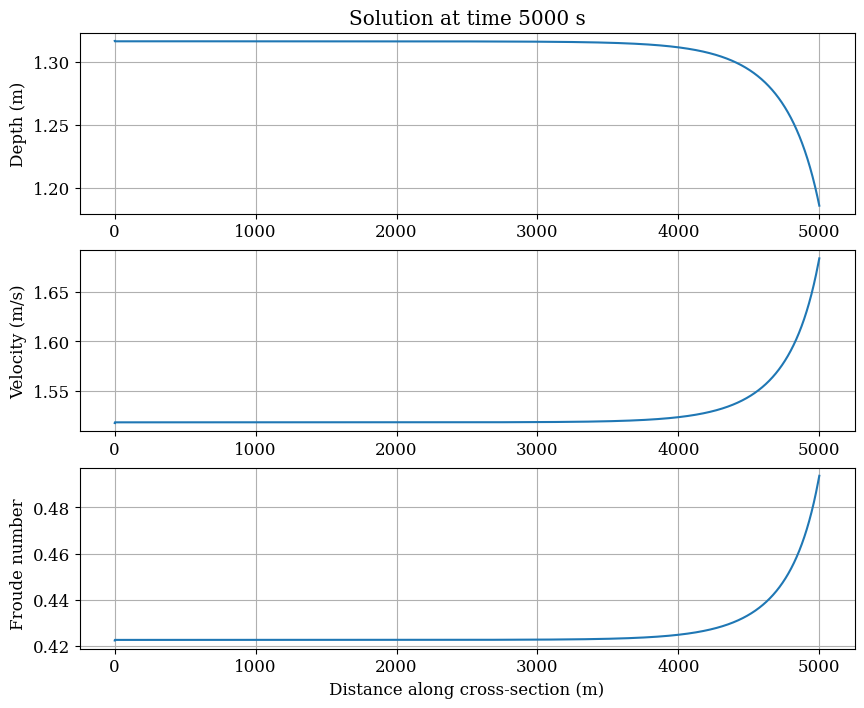

In [29]:
claw=setup(L,q,h0,h_upstream,h_downstream,K,i,mx,tf,nbo,method=method)
claw.run()


# --- Setup of the figure ---
fig, ((ax, axu,ax_fr) ) = plt.subplots(3, 1)
fig.set_figheight(8)
fig.set_figwidth(10)
#ax.set_xlabel("Distance along cross-section (m)")
ax.set_ylabel("Depth (m)")
ax.grid()
x = claw.frames[0].grid.dimensions[0].centers
ax.plot(x,claw.frames[-1].q[0, :])

#axu.set_xlabel("Distance along cross-section (m)")
axu.set_ylabel("Velocity (m/s)")
axu.grid()
axu.plot(x,claw.frames[-1].q[1, :]/claw.frames[-1].q[0, :])
#axu.set_ylim([])

ax_fr.set_xlabel("Distance along cross-section (m)")
ax_fr.set_ylabel("Froude number  ")
ax_fr.grid()
ax_fr.plot(x,claw.frames[-1].q[1, :]/claw.frames[-1].q[0, :]**1.5/np.sqrt(9.81))
ax.set_title(f"Solution at time {claw.frames[-1].t:.0f} s")
fig.savefig("solution2.png",dpi=300,bbox_inches='tight')

In [30]:
# Flow depth animation
anim = flow_animation(claw,K,q,i,L)
HTML(anim.to_jshtml())

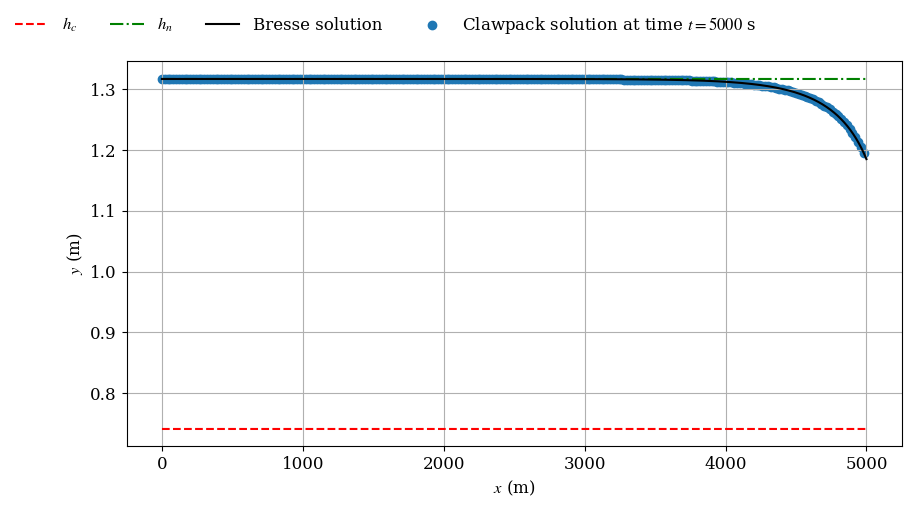

In [37]:
# Comparison with the Bresse solution
fig, ax = plt.subplots(figsize=(10,5))

ax.set_ylabel(r'$h(x) (m)$')
ax.set_xlabel(r'$x$ (m)')

ax.grid()
ax.plot(x,hc*np.ones(len(x)),'r--',label=r'$h_c$')
ax.plot(x,hn*np.ones(len(x)),'g-.',label=r'$h_n$')
#ax.set_ylim((0, 4))

def add_true_solution(claw,plot_normal_depth=False,density=20):
    """ Plot the last numerical solution given by clawpack """
    if plot_normal_depth:
        x     = frame.state.grid.x.centers
        Qout  = claw.problem_data['flow_rate']
        slope = claw.problem_data['slope']
        n     = 1/claw.problem_data['Strickler']
        normal_depth = (Qout/np.sqrt(abs(slope))*n)**0.6
        qtrue=np.empty(x.shape[0]); qtrue.fill(normal_depth)
        ax.plot(x, qtrue, 'r--')
    index = np.size(claw.frames)-1
    frame = claw.frames[index]
    b  = frame.aux[0,:]
    h  = frame.q[0,:]
    hu = frame.q[1,:]
    u  = hu/h
    x = frame.state.grid.x.centers  
    t = claw.frames[index].t
    ax.scatter(x[::density],h[::density],label = rf"Clawpack solution at time $t={t:.0f}$ s")

def add_bresse_solution(claw,h0,hn,hc):
    """Plot the solution to the Bresse equation"""
    from scipy import integrate
    # grid
    
    if hn>hc:
        x = np.linspace(L,0,mx)
    else:
        x = np.linspace(0,L,mx)
    
    #solution
    sol = integrate.odeint(bresse,h0,x,args=(i,hn,hc))
    ax.plot(x, sol, '-k',label='Bresse solution')




#ax.set_ylim((0.8*hn,1.1*hn))

add_bresse_solution(claw,h_downstream,hn,hc)
add_true_solution(claw)
ax.set_xlabel(r'$x$ (m)')
ax.set_ylabel(r'$y$ (m)')

fig.legend(loc="upper left",ncol=4,frameon=False)
plt.show()
fig.savefig("steady-state_comparison-Bresse-StV.png",dpi=300,bbox_inches = 'tight')

# Animation flow rate and velocity

In [ ]:
def flow_animation_rate(claw):
    """ 
    Animation for the flow rate
    """
    import matplotlib.animation
    import numpy
    from math import ceil

    index = np.size(claw.frames)-1
    qm = ceil(max(claw.frames[index].q[1,:])) *1.2
    #qm = 1.25
     
    x = claw.frames[0].grid.dimensions[0].centers
    x_true = numpy.linspace(0., L , 500)
    
    h0  = claw.problem_data['initial_depth']
    hn, hc = CharacteristicDepth(K,q,i)
    qn = claw.problem_data['flow_rate']
     
    fig = plt.figure()
    axes = plt.subplot(1, 1, 1)
    
    axes.set_xlabel(r'$x$',fontsize=14)
    axes.set_ylabel(r'$q(x, t)$',fontsize=14)
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim(( 0.8, qm))
    axes.set_title(" ")
    text = axes.text(L/2, 0.9*qm , '')
 
    def init():
 

        computed_line, = axes.plot(x[0], claw.frames[0].q[1, :][0], 'r')
        exact_line, = axes.plot(x_true[0], qn, 'k--')
        return  (computed_line, exact_line)
    
    computed_line, exact_line = init()
 
    
    def fplot(n):
        computed_line.set_data([x,], [claw.frames[n].q[1, :]])
        exact_line.set_data([x_true], [np.ones(np.size(x_true))*qn])
        tt = claw.frames[n].t
        val = f'{tt:.2f}'
        text.set_text(r'$ t = {} $ s'.format(val))
        #text.set_text(rf't = {tt:.2f} s' )
        return (computed_line, exact_line)

    frames_to_plot = range(0, len(claw.frames))
    plt.close(fig)
    return matplotlib.animation.FuncAnimation(fig, fplot, frames=frames_to_plot, interval=100,
                                   blit=True, init_func=None, repeat=False)


from IPython.display import HTML 
anim = flow_animation_rate(claw)
HTML(anim.to_jshtml())

In [ ]:
def flow_animation_velocity(claw):
    """animation for the flow velocity"""
    import matplotlib.animation
    import numpy
    from math import ceil, floor

    index = np.size(claw.frames)-1
    qm = (max(claw.frames[index].q[1,:])) 
    hm = (min(claw.frames[index].q[0,:])) 
    x = claw.frames[0].grid.dimensions[0].centers
    x_true = numpy.linspace(0., L , 500)
    
    h0  = claw.problem_data['initial_depth']
    hn, hc = CharacteristicDepth(K,q,i)
    un = q/hn
    um = qm/hm*1.2

    fig = plt.figure()
    axes = plt.subplot(1, 1, 1)
  
    axes.set_xlabel(r'$x$',fontsize=14)
    axes.set_ylabel(r'$u(x, t)$',fontsize=14)
    axes.set_xlim((x[0], x[-1]))
    #axes.set_ylim(( 0, um))
    axes.set_title(" ")
    text = axes.text(L/2, 0.9*um , '')
 
    def init():
        axes.set_xlim((x[0], x[-1]))
        axes.set_ylim((0,um))

        computed_line, = axes.plot(x[0], claw.frames[0].q[1, :][0]/claw.frames[0].q[0, :][0], 'r')
        exact_line, = axes.plot(x_true[0], un, 'k--')
        return  (computed_line, exact_line)
    
    computed_line, exact_line = init()
 
    
    def fplot(n):
        computed_line.set_data([x,], [ claw.frames[n].q[1, :]/claw.frames[n].q[0, :] ])
        exact_line.set_data([x_true], [ un*np.ones(np.size(x_true)) ])
        tt = claw.frames[n].t
        val = f'{tt:.2f}'
        text.set_text(r'$ t = {} $ s'.format(val))
        #text.set_text(rf't = {tt:.2f} s' )
        return (computed_line, exact_line)

    frames_to_plot = range(0, len(claw.frames))
    plt.close(fig)
    return matplotlib.animation.FuncAnimation(fig, fplot, frames=frames_to_plot, interval=100,
                                   blit=True, init_func=None, repeat=False)



anim = flow_animation_velocity(claw)
HTML(anim.to_jshtml())